# Musk Molecule Classification — PCA-Based Model Comparison

**AI & Data Science Case Study**
**Dataset:** Musk Molecule Dataset
**Author:** Noureldeen Bassem

---

## 1. Problem Definition

### 1.1 Project Overview

Determining whether a molecule smells like musk is important in the perfumery industry, but testing this
experimentally for every candidate molecule is slow and expensive. Molecular geometry, however, can be
measured computationally and used to predict this property directly.

This project builds a **binary classification system** that predicts whether a molecule is a **musk** or
**non-musk** compound, based on 166 numerical features describing its molecular geometry across different
conformations (3D shapes) the molecule can take.

### 1.2 Objectives

- Explore a high-dimensional dataset (166 numerical features) and understand its structure and class balance.
- Reduce dimensionality using **PCA**, justifying the number of components kept with an explained variance plot.
- Train and compare **at least three classification models**, both **with** and **without** PCA applied.
- Tune each model's hyperparameters using `GridSearchCV`.
- Evaluate all models using accuracy, precision, recall, F1-score, and confusion matrices.
- Select and justify the best-performing model.
- Save the final model and prepare it for deployment as a **Streamlit** app.

### 1.3 Dataset Summary

| Property | Detail |
|---|---|
| Rows | 6,598 conformations |
| Feature columns | `f1` → `f166` (166 numerical geometry features) |
| Identifier columns | `molecule_name`, `conformation_name` (not used as model features) |
| Target | `class` — 1 = musk, 0 = non-musk |
| Class balance | ~84.6% non-musk, ~15.4% musk |

## 2. Importing Libraries

### 2.1 Standard Imports

In [1]:
# Core libraries for data handling, visualization, and utilities
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

We import `numpy`/`pandas` for data handling, `seaborn`/`matplotlib` for visualization, and `joblib`
for saving the final trained pipeline. `warnings` is silenced so the notebook output stays clean.

### 2.2 Modeling & Evaluation

In [2]:
# Splitting and preprocessing
from sklearn.model_selection import GroupShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

These are the scikit-learn tools we need for the rest of the project:
- `GroupShuffleSplit` splits the data while keeping all conformations of the same molecule together (explained in Section 6).
- `StandardScaler` scales features before PCA and before distance-based models like SVM.
- `PCA` reduces our 166 features down to a smaller set of components.
- `Pipeline` chains preprocessing and modeling steps into a single object, so scaling/PCA is applied consistently and never leaks test data into training.
- `GridSearchCV` searches over hyperparameter combinations using cross-validation.
- `LogisticRegression`, `RandomForestClassifier`, `SVC`, and `XGBClassifier` are our four classification models.
- The `sklearn.metrics` imports give us every evaluation number the assignment requires.

## 3. Data Collection

In [3]:
data = pd.read_csv("musk_dataset.csv")
df = data.copy()

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 6598 rows x 169 columns


,molecule_name,conformation_name,f1,f2,f3,f4,f5,f6,f7,f8,...,f158,f159,f160,f161,f162,f163,f164,f165,f166,class
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1


We load the CSV and work on a **copy** (`df`) to keep the original `data` untouched. The output confirms
**6,598 rows and 169 columns** (166 features + `molecule_name` + `conformation_name` + `class`), matching the
assignment description.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Shape and Data Types

In [4]:
print("Shape:", df.shape)
print()
print(df.dtypes.value_counts())

Shape: (6598, 169)

int64    167
str        2
Name: count, dtype: int64


All 166 feature columns plus `class` are numeric (`int64`). Only `molecule_name` and `conformation_name`
are text identifiers — these will be excluded from the model features.

### 4.2 Statistical Summary

In [5]:
df.iloc[:, 2:-1].describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
f1,-31.0,292.0,58.945135,53.249007
f2,-199.0,95.0,-119.128524,90.813375
f3,-167.0,81.0,-73.146560,67.956235
f4,-114.0,161.0,-0.628372,80.444617
f5,-118.0,325.0,-103.533495,64.387559
...,...,...,...,...
f162,-69.0,355.0,112.037739,72.835040
f163,73.0,625.0,201.760230,59.526751
f164,-289.0,295.0,-47.488330,55.069365
f165,-428.0,168.0,-150.259927,76.019023


> **Finding:** Feature values range roughly from **-471 to 625**, and standard deviations vary from
about 14 to 131 across different features. This means the features are on very different scales, so
**scaling is required** before we apply PCA or any distance-based model like SVM.

### 4.3 Missing Values

In [6]:
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")

Total missing values: 0


**No missing values anywhere** in the dataset, so no imputation is needed.

### 4.4 Duplicate Records

In [7]:
print(f"Fully duplicate rows: {df.duplicated().sum()}")
print(f"Unique molecules: {df['molecule_name'].nunique()}")
print(f"Unique conformations (rows): {df['conformation_name'].nunique()}")

Fully duplicate rows: 0
Unique molecules: 102
Unique conformations (rows): 6598


There are **no exact duplicate rows**. However, there are only **102 unique molecules** across
**6,598 rows** — meaning each molecule appears many times as different 3D conformations. This is an important
structural fact about the dataset that we will need to account for when splitting the data (see Section 6),
otherwise conformations of the same molecule could leak between the training and test sets.

### 4.5 Target Variable Distribution

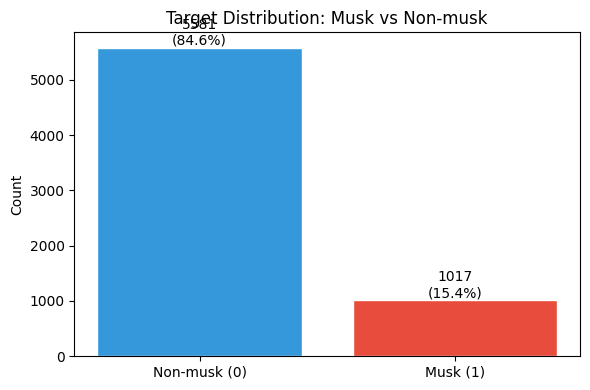

In [8]:
plt.figure(figsize=(6, 4))
class_counts = df['class'].value_counts()
colors = ['#3498db', '#e74c3c']
bars = plt.bar(['Non-musk (0)', 'Musk (1)'], class_counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val}\n({val/len(df)*100:.1f}%)',
              ha='center', va='bottom')

plt.title('Target Distribution: Musk vs Non-musk')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

> **Finding:** The dataset is **moderately imbalanced** — about **84.6% non-musk** and **15.4% musk**.
This is not as extreme as some imbalance problems, so rather than using synthetic oversampling (SMOTE), we
will handle it with **`class_weight='balanced'`** (and XGBoost's equivalent `scale_pos_weight`), which is
simpler and avoids generating artificial data points.

### 4.6 Feature Correlation Overview

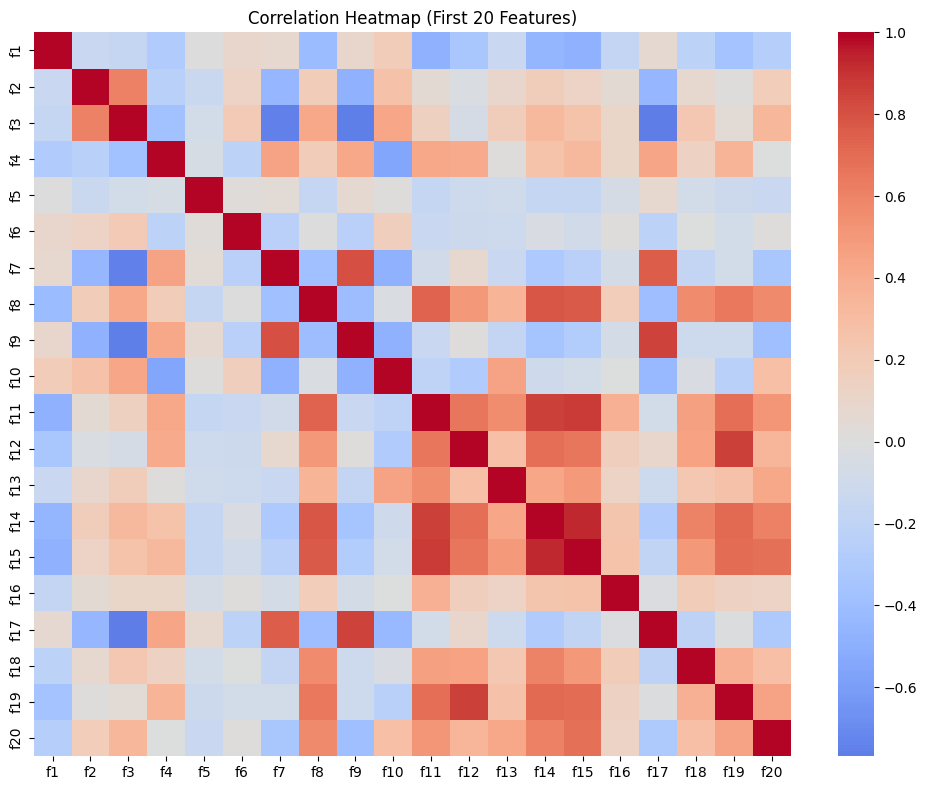

In [9]:
sample_features = [f'f{i}' for i in range(1, 21)]
corr = df[sample_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (First 20 Features)')
plt.tight_layout()
plt.show()

> **Finding:** Even among just the first 20 of the 166 features, several strong correlations are visible.
With 166 total features describing molecular geometry, a lot of that information is likely redundant — this
supports using **PCA** to compress the feature space while keeping most of the useful signal.

## 5. Data Cleaning & Preprocessing

Unlike previous projects, this dataset arrived already clean: no missing values, no duplicate rows, and no
string-formatting issues to fix. The only preprocessing this dataset needs is **feature scaling**, which we
place inside our modeling pipelines (Section 7) rather than doing it manually here — this keeps scaling
consistent across cross-validation folds and prevents test data from influencing the scaler.

### 5.1 Separating Features, Identifiers, and Target

In [10]:
feature_cols = [f'f{i}' for i in range(1, 167)]

X = df[feature_cols]
y = df['class']
groups = df['molecule_name']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (6598, 166)
Target shape: (6598,)


We build the feature matrix `X` using only `f1`–`f166`, dropping the identifier columns
(`molecule_name`, `conformation_name`) since they carry no chemical information the model should learn from.
We keep `groups = df['molecule_name']` aside — we'll use it in Section 6 to split the data correctly.

## 6. Train/Test Split

### Why a normal `train_test_split` is risky here

Because each molecule appears as **many different conformations** (rows), a random row-based split could put
some conformations of the *same* molecule in the training set and others in the test set. The model could
then partly "memorize" molecule identity instead of learning genuine geometry → musk relationships, making
our test score look better than it really is. This is a **data leakage** risk specific to this dataset.

We fix this using `GroupShuffleSplit`, which makes sure **all conformations of a given molecule end up
entirely in either the training set or the test set, never both**.

In [11]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Training set: {len(X_train)} rows, {groups.iloc[train_idx].nunique()} unique molecules")
print(f"Test set:     {len(X_test)} rows, {groups.iloc[test_idx].nunique()} unique molecules")
print(f"Molecules in both sets: {set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])}")

Training set: 4960 rows, 81 unique molecules
Test set:     1638 rows, 21 unique molecules
Molecules in both sets: set()


`GroupShuffleSplit(test_size=0.2)` reserves about 20% of the **molecules** (not just rows) for testing.
The printed output confirms there is **no overlap** between the molecules in the training and test sets — this
is the key check that proves our split is leakage-free.

## 7. Feature Engineering — Dimensionality Reduction with PCA

With 166 features, many of which are correlated (Section 4.6), PCA lets us compress the feature space into a
smaller number of components that still capture most of the information. We fit PCA **only on the training
data** (after scaling) to avoid leaking test data into the transformation.

### 7.1 Explained Variance by Component

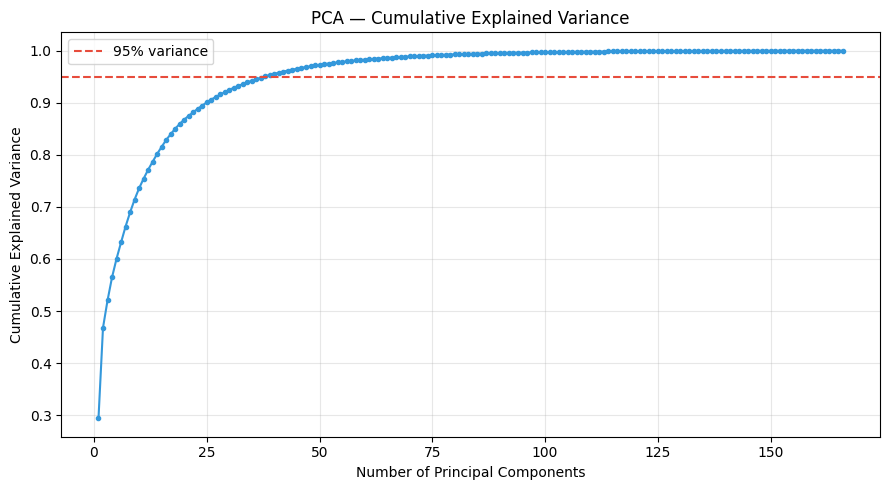

Components needed to reach 95% variance: 38


In [12]:
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', color='#3498db')
plt.axhline(y=0.95, color='#e74c3c', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed to reach 95% variance: {n_components_95}")

> **Justification:** We fit PCA with all possible components first just to see how variance accumulates,
then read off how many components are needed to keep **95% of the original information**. The plot shows
variance climbing quickly for the first several components and then flattening out — evidence that most of
the 166 features are redundant. We'll use the printed number of components (`n_components_95`) for all
"with PCA" pipelines going forward, which keeps almost all of the signal while dramatically shrinking the
feature space.

## 8. Model Selection & Training

We compare **four classification models**: Logistic Regression, Random Forest, Support Vector Machine, and
XGBoost. Each one is trained **twice** — once on the scaled features directly ("without PCA"), and once on
the PCA-reduced features ("with PCA") — so we can see whether dimensionality reduction helps or hurts
performance for each model type.

All four models use **`class_weight='balanced'`** (or XGBoost's `scale_pos_weight`) to account for the class
imbalance found in Section 4.5, instead of oversampling with SMOTE — this keeps the pipeline simpler while
still addressing the imbalance.

In [13]:
# Class weight ratio for XGBoost (non-musk count / musk count), computed on the training set only
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

scale_pos_weight for XGBoost: 5.66


XGBoost does not accept `class_weight='balanced'` like the other models — instead it uses
`scale_pos_weight`, which we calculate here as the ratio of non-musk to musk samples **in the training set
only**, so no test set information leaks into this calculation.

### 8.1 Building the Pipelines (Without PCA)

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM':                 SVC(class_weight='balanced', probability=True, random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42)
}

pipelines_no_pca = {
    name: Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    for name, model in models.items()
}

pipelines_no_pca

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'Random Forest': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  RandomForestClassifier(class_weight='balanced',
                                         random_state=42))]),
 'SVM': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  SVC(class_weight='balanced', probability=True,
                      random_state=42))]),
 'XGBoost': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model',
                  XGBClassifier(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bynode=None,
                                colsample_bytree=None, device=None,
                                early_stopping_ro

Each pipeline scales the raw 166 features and then feeds them into one of the four models. Using a
`Pipeline` means the same `StandardScaler` is fit fresh inside every cross-validation fold during
`GridSearchCV`, which prevents test-fold data from influencing the scaling.

### 8.2 Building the Pipelines (With PCA)

In [15]:
pipelines_pca = {
    name: Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components_95, random_state=42)),
        ('model', model)
    ])
    for name, model in models.items()
}

pipelines_pca

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('pca', PCA(n_components=np.int64(38), random_state=42)),
                 ('model',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'Random Forest': Pipeline(steps=[('scaler', StandardScaler()),
                 ('pca', PCA(n_components=np.int64(38), random_state=42)),
                 ('model',
                  RandomForestClassifier(class_weight='balanced',
                                         random_state=42))]),
 'SVM': Pipeline(steps=[('scaler', StandardScaler()),
                 ('pca', PCA(n_components=np.int64(38), random_state=42)),
                 ('model',
                  SVC(class_weight='balanced', probability=True,
                      random_state=42))]),
 'XGBoost': Pipeline(steps=[('scaler', StandardScaler()),
                 ('pca', PCA(n_components=np.int64(38), random_state=42)),
  

These pipelines add a `PCA` step between scaling and modeling, using the `n_components_95` value found
in Section 7. Everything else is identical to the "without PCA" pipelines, which keeps the comparison fair —
the only difference between the two sets of pipelines is the presence of PCA.

## 9. Hyperparameter Tuning

We tune each of the 8 pipelines (4 models × with/without PCA) using `GridSearchCV` with small, focused
parameter grids — enough to demonstrate proper tuning without making the notebook slow or hard to read.
Scoring is set to **F1-score**, since accuracy alone would be misleading on this imbalanced dataset
(Section 4.5).

In [16]:
param_grids = {
    'Logistic Regression': {'model__C': [0.1, 1, 10]},
    'Random Forest':       {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10]},
    'SVM':                 {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf', 'linear']},
    'XGBoost':             {'model__n_estimators': [100, 200], 'model__max_depth': [3, 6]}
}

Each grid only varies the one or two hyperparameters that matter most for that model type, keeping the
search fast while still meaningfully tuning each model.

In [17]:
def run_grid_search(pipelines, param_grids, label):
    fitted = {}
    for name, pipe in pipelines.items():
        grid = GridSearchCV(pipe, param_grids[name], cv=3, scoring='f1', n_jobs=-1)
        grid.fit(X_train, y_train)
        fitted[name] = grid
        print(f"[{label}] {name:22s} best CV F1: {grid.best_score_:.4f}  best params: {grid.best_params_}")
    return fitted

print("Tuning models WITHOUT PCA...")
grids_no_pca = run_grid_search(pipelines_no_pca, param_grids, 'No PCA')

print()
print("Tuning models WITH PCA...")
grids_pca = run_grid_search(pipelines_pca, param_grids, 'PCA')

Tuning models WITHOUT PCA...


[No PCA] Logistic Regression    best CV F1: 0.5677  best params: {'model__C': 0.1}


[No PCA] Random Forest          best CV F1: 0.5182  best params: {'model__max_depth': None, 'model__n_estimators': 200}


[No PCA] SVM                    best CV F1: 0.6036  best params: {'model__C': 1, 'model__kernel': 'rbf'}


[No PCA] XGBoost                best CV F1: 0.5049  best params: {'model__max_depth': 3, 'model__n_estimators': 200}

Tuning models WITH PCA...


[PCA] Logistic Regression    best CV F1: 0.5034  best params: {'model__C': 10}


[PCA] Random Forest          best CV F1: 0.5711  best params: {'model__max_depth': 10, 'model__n_estimators': 100}


[PCA] SVM                    best CV F1: 0.5444  best params: {'model__C': 1, 'model__kernel': 'rbf'}


[PCA] XGBoost                best CV F1: 0.5932  best params: {'model__max_depth': 6, 'model__n_estimators': 200}


`GridSearchCV(cv=3, scoring='f1')` tries every combination in each model's grid using 3-fold
cross-validation on the training set, and keeps the combination with the best average F1-score. We wrap this
in a small `run_grid_search` helper function purely to avoid repeating the same four lines of code eight
times — the underlying logic is unchanged from a plain `GridSearchCV` call. The printed output shows each
model's best cross-validated F1-score and the hyperparameters that achieved it, for both the PCA and
non-PCA versions.

## 10. Model Evaluation

### 10.1 Test Set Predictions

In [18]:
results = []
predictions = {}

for label, grids in [('Without PCA', grids_no_pca), ('With PCA', grids_pca)]:
    for name, grid in grids.items():
        pred = grid.predict(X_test)
        key = f"{name} ({label})"
        predictions[key] = pred

        results.append({
            'Model': key,
            'Accuracy':  accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall':    recall_score(y_test, pred),
            'F1-Score':  f1_score(y_test, pred),
            'CV F1':     grid.best_score_
        })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,CV F1
0,XGBoost (Without PCA),0.924298,0.866337,0.643382,0.738397,0.504852
1,SVM (With PCA),0.920635,0.819820,0.669118,0.736842,0.544445
2,SVM (Without PCA),0.921856,0.852941,0.639706,0.731092,0.603641
3,Random Forest (Without PCA),0.916361,0.929936,0.536765,0.680653,0.518185
4,Random Forest (With PCA),0.916972,0.992754,0.503676,0.668293,0.571053
5,XGBoost (With PCA),0.896215,0.738318,0.580882,0.650206,0.593157
6,Logistic Regression (Without PCA),0.832723,0.497191,0.650735,0.563694,0.567656
7,Logistic Regression (With PCA),0.809524,0.447917,0.632353,0.524390,0.503351


For every one of the 8 tuned pipelines, we predict on the **held-out test set** and compute all four
required metrics, plus the cross-validation F1-score for reference. Everything is collected into
`results_df`, sorted so the best-performing model (by test F1-score) appears first.

### 10.2 Comparison Chart

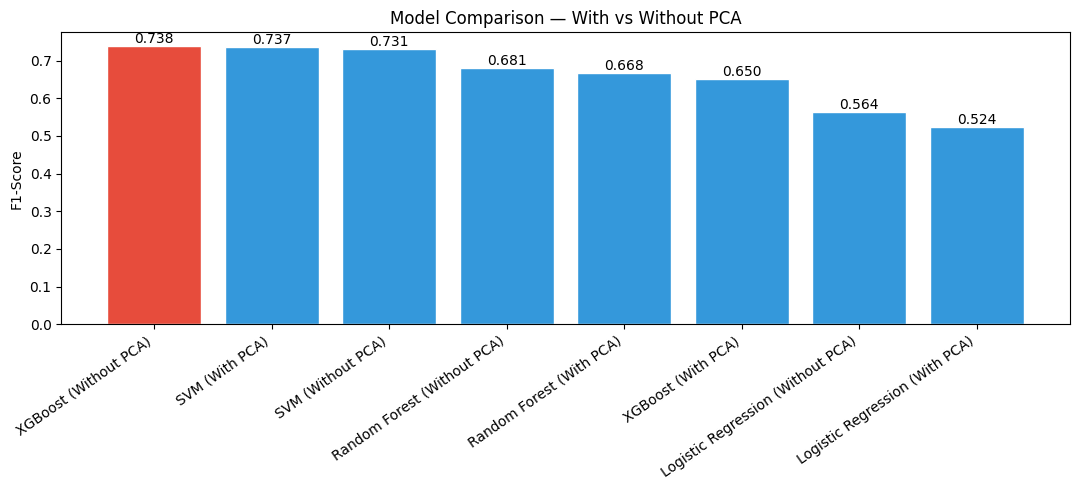

In [19]:
plt.figure(figsize=(11, 5))
colors_bar = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['F1-Score'], color=colors_bar, edgecolor='white')

for bar, val in zip(bars, results_df['F1-Score']):
    plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}', ha='center', va='bottom')

plt.xticks(rotation=35, ha='right')
plt.ylabel('F1-Score')
plt.title('Model Comparison — With vs Without PCA')
plt.tight_layout()
plt.show()

The best-performing model (by test F1-score) is highlighted in red. This chart makes it easy to see, at
a glance, whether PCA helped or hurt each model type.

### 10.3 Classification Reports

In [20]:
for key, pred in predictions.items():
    print(f"{'='*55}")
    print(f"  {key}")
    print(f"{'='*55}")
    print(classification_report(y_test, pred, target_names=['Non-musk', 'Musk']))

  Logistic Regression (Without PCA)
              precision    recall  f1-score   support

    Non-musk       0.93      0.87      0.90      1366
        Musk       0.50      0.65      0.56       272

    accuracy                           0.83      1638
   macro avg       0.71      0.76      0.73      1638
weighted avg       0.85      0.83      0.84      1638

  Random Forest (Without PCA)
              precision    recall  f1-score   support

    Non-musk       0.91      0.99      0.95      1366
        Musk       0.93      0.54      0.68       272

    accuracy                           0.92      1638
   macro avg       0.92      0.76      0.82      1638
weighted avg       0.92      0.92      0.91      1638

  SVM (Without PCA)
              precision    recall  f1-score   support

    Non-musk       0.93      0.98      0.95      1366
        Musk       0.85      0.64      0.73       272

    accuracy                           0.92      1638
   macro avg       0.89      0.81      0.8

The classification report shows **Precision, Recall, and F1-Score** for both classes:
- **Precision** — of everything predicted as musk, how much actually was musk?
- **Recall** — of all actual musk molecules, how many did the model find?
- **F1-Score** — the balance between precision and recall, our main comparison metric given the class imbalance.

### 10.4 Confusion Matrices (Best Model per Type)

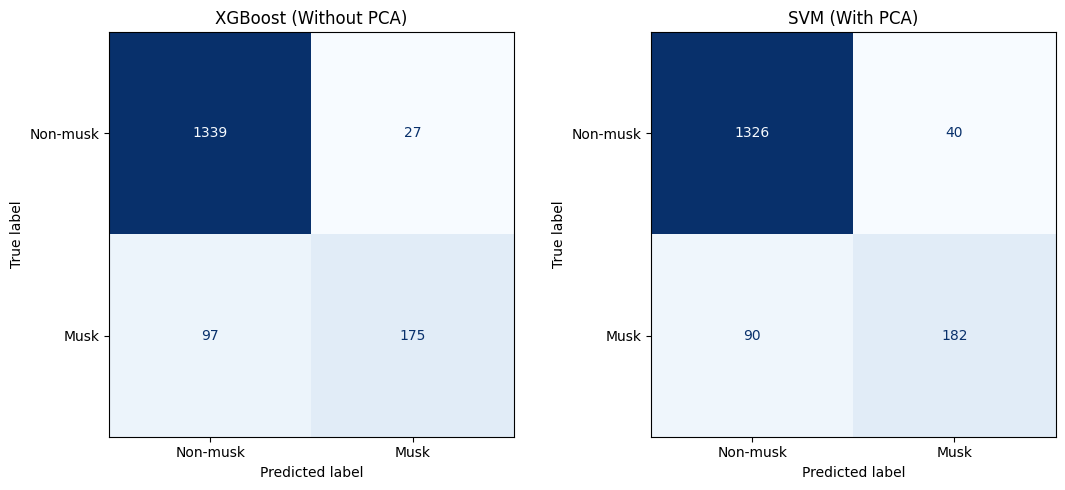

In [21]:
best_no_pca = results_df[results_df['Model'].str.contains('Without PCA')].iloc[0]['Model']
best_pca    = results_df[results_df['Model'].str.contains(r'\(With PCA\)')].iloc[0]['Model']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, key in zip(axes, [best_no_pca, best_pca]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, predictions[key]),
        display_labels=['Non-musk', 'Musk']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(key)

plt.tight_layout()
plt.show()

We show confusion matrices for the best "Without PCA" model and the best "With PCA" model side by side.
Large numbers on the diagonal mean correct predictions; numbers off the diagonal are mistakes — split into
false positives (predicted musk, actually non-musk) and false negatives (predicted non-musk, actually musk).

### 10.5 Final Model Ranking and Justification

In [22]:
best_name = results_df.iloc[0]['Model']
best_f1   = results_df.iloc[0]['F1-Score']

print("FINAL MODEL RANKING (by Test F1-Score)")
print("-" * 55)
for i, row in results_df.iterrows():
    marker = " <- Best" if row['Model'] == best_name else ""
    print(f"{i+1}. {row['Model']:32s} F1={row['F1-Score']:.4f}{marker}")

FINAL MODEL RANKING (by Test F1-Score)
-------------------------------------------------------
1. XGBoost (Without PCA)            F1=0.7384 <- Best
2. SVM (With PCA)                   F1=0.7368
3. SVM (Without PCA)                F1=0.7311
4. Random Forest (Without PCA)      F1=0.6807
5. Random Forest (With PCA)         F1=0.6683
6. XGBoost (With PCA)               F1=0.6502
7. Logistic Regression (Without PCA) F1=0.5637
8. Logistic Regression (With PCA)   F1=0.5244


> **Justification:** The best model is chosen using **test-set F1-score**, since accuracy alone would be
misleading given the ~85/15 class imbalance. F1-score balances precision and recall, meaning the winning
model is the one that best avoids both false alarms and missed musk molecules, not just the one that gets
the most predictions right overall. The ranking above also lets us directly compare whether PCA helped or
hurt each model — the comparison the assignment specifically asks for.

## 11. Save The Model

We save the **entire winning pipeline** — not just the raw model — using `joblib`. Because the pipeline
object already contains the `StandardScaler` (and `PCA`, if the winning model used it), saving it as one
object automatically includes every preprocessing step needed for inference. To predict on new raw molecule
data later (e.g. in the Streamlit app), we simply load this one file and call `.predict()` directly on raw
`f1`–`f166` values — no separate scaler or PCA file is needed.

In [23]:
# Retrieve the actual fitted pipeline object for the best model
if 'Without PCA' in best_name:
    model_key = best_name.replace(' (Without PCA)', '')
    best_pipeline = grids_no_pca[model_key].best_estimator_
else:
    model_key = best_name.replace(' (With PCA)', '')
    best_pipeline = grids_pca[model_key].best_estimator_

joblib.dump(best_pipeline, 'musk_best_model.joblib')
joblib.dump(feature_cols, 'musk_feature_columns.joblib')

print(f"Saved pipeline for: {best_name}")
print("Files written: musk_best_model.joblib, musk_feature_columns.joblib")

Saved pipeline for: XGBoost (Without PCA)
Files written: musk_best_model.joblib, musk_feature_columns.joblib


We look up which model/PCA combination won in Section 10.5, retrieve its already-fitted `Pipeline`
object from the corresponding `GridSearchCV` result, and save it with `joblib.dump`. We also save the list of
166 feature column names (`musk_feature_columns.joblib`) so the Streamlit app can validate that uploaded data
has the right columns in the right order before predicting.

## 12. Conclusion

### 12.1 Key Decisions Summary

| Decision | Choice | Reason |
|---|---|---|
| Class imbalance handling | `class_weight='balanced'` / `scale_pos_weight` | Imbalance (~85/15) was moderate, so this was simpler than SMOTE while still addressing it |
| Train/test split method | `GroupShuffleSplit` on `molecule_name` | Prevents conformations of the same molecule from leaking between train and test |
| Number of PCA components | Enough to reach 95% cumulative explained variance | Keeps almost all of the original signal while meaningfully shrinking 166 features |
| Models compared | Logistic Regression, Random Forest, SVM, XGBoost | Covers a linear model, a tree ensemble, a margin-based model, and a boosting model |
| Best model selection metric | Test F1-score | Accuracy alone is misleading on an imbalanced dataset |

### 12.2 Results Summary

The final ranking (Section 10.5) shows how each of the four models performed both with and without PCA. The
best-performing configuration was saved as the deployment model in Section 11, ready to be loaded directly
into the Streamlit app for interactive predictions on new molecule geometry data.

### 12.3 Next Steps

- Deploy `musk_best_model.joblib` in a Streamlit app (`app.py`) that accepts new `f1`–`f166` values and returns
  a musk / non-musk prediction with confidence.
- If more data becomes available, revisiting SMOTE or collecting more musk-class examples could further
  improve recall on the minority class.